# PS5 — Maximum Capacity: All 207 Orbit Types
## Option C: HH Delay-Directed Orbit Selection
### HHSMC Project — February 2026

**Purpose:** Find the true memory capacity N*_max of the HH-DFC system by testing all 207 orbit types from PS0, building a full pairwise confusion matrix, and greedily selecting the largest mutually distinguishable subset.

**Prerequisite:** PS0 complete (207 orbit types), PS2 complete (POLD classifier)

**Phases:**
- **A** — Load all 207 orbit types from PS0, build POLD templates
- **B** — Pairwise confusion matrix: classify each orbit against all others
- **C** — Greedy selection: find largest subset with all pairs ≥90% distinguishable
- **D** — Capacity curve for selected subset
- **E** — Final comparison: N*_max vs N*_conservative (12) vs N*_rate (6)
- **F** — Gate PS-G5 evaluation

**Gate PS-G5:** N*_max >= 12 (conservative set was not the ceiling)

**Numba:** NO `cache=True`, NO `np.clip` — uses `clamp01()`

## CELL 1 — Setup

In [1]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, os, time
from datetime import datetime
from itertools import combinations

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE       = '/content/drive/My Drive/HHSMC/full_study'
    PS0_DIR    = BASE + '/PS0_orbit_catalogue'
    PS1_DIR    = BASE + '/PS1_write_protocol'
    PS2_DIR    = BASE + '/PS2_read_protocol'
    OUTPUT_DIR = BASE + '/PS5_max_capacity'
except ImportError:
    PS0_DIR    = './PS0_results'
    PS1_DIR    = './PS1_results'
    PS2_DIR    = './PS2_results'
    OUTPUT_DIR = './PS5_results'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('PS0 input:  ', PS0_DIR)
print('PS5 output: ', OUTPUT_DIR)
print('Timestamp:  ', datetime.now().isoformat())
print('Phase PS5 -- Maximum Capacity from All 207 Orbit Types')

Mounted at /content/drive
PS0 input:   /content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue
PS5 output:  /content/drive/My Drive/HHSMC/full_study/PS5_max_capacity
Timestamp:   2026-03-06T18:30:05.476192
Phase PS5 -- Maximum Capacity from All 207 Orbit Types


## CELL 2 — HH Model (V-shifted, rest=0) — NO cache=True, NO np.clip

In [2]:
C_M=1.0; G_NA=120.0; G_K=36.0; G_L=0.3
E_NA=115.0; E_K=-12.0; E_L=10.6; DT=0.01

@njit
def alpha_m(V):
    x = 25.0 - V
    if abs(x) < 1e-7: return 1.0
    return 0.1 * x / (np.exp(x/10.0) - 1.0)

@njit
def beta_m(V): return 4.0 * np.exp(-V/18.0)

@njit
def alpha_h(V): return 0.07 * np.exp(-V/20.0)

@njit
def beta_h(V): return 1.0 / (np.exp((30.0-V)/10.0) + 1.0)

@njit
def alpha_n(V):
    x = 10.0 - V
    if abs(x) < 1e-7: return 0.1
    return 0.01 * x / (np.exp(x/10.0) - 1.0)

@njit
def beta_n(V): return 0.125 * np.exp(-V/80.0)

@njit
def clamp01(x):
    if x < 0.0: return 0.0
    if x > 1.0: return 1.0
    return x

@njit
def hh_rhs(V, m, h, n, I):
    dV = (I - G_NA*m*m*m*h*(V-E_NA) - G_K*n*n*n*n*(V-E_K) - G_L*(V-E_L)) / C_M
    dm = alpha_m(V)*(1.0-m) - beta_m(V)*m
    dh = alpha_h(V)*(1.0-h) - beta_h(V)*h
    dn = alpha_n(V)*(1.0-n) - beta_n(V)*n
    return dV, dm, dh, dn

@njit
def hh_ss(V):
    am=alpha_m(V); bm=beta_m(V)
    ah=alpha_h(V); bh=beta_h(V)
    an=alpha_n(V); bn=beta_n(V)
    return am/(am+bm), ah/(ah+bh), an/(an+bn)

print('HH model defined.')

HH model defined.


## CELL 3 — Simulation Engine (simulate_clean — identical to PS2/PS3)

In [3]:
@njit
def rk4_step(V, m, h, n, I_bias, K, V_delayed, dt):
    I1 = I_bias + K*(V_delayed - V)
    dV1,dm1,dh1,dn1 = hh_rhs(V, m, h, n, I1)
    Vk2=V+.5*dt*dV1; mk2=m+.5*dt*dm1; hk2=h+.5*dt*dh1; nk2=n+.5*dt*dn1
    I2 = I_bias + K*(V_delayed - Vk2)
    dV2,dm2,dh2,dn2 = hh_rhs(Vk2,mk2,hk2,nk2,I2)
    Vk3=V+.5*dt*dV2; mk3=m+.5*dt*dm2; hk3=h+.5*dt*dh2; nk3=n+.5*dt*dn2
    I3 = I_bias + K*(V_delayed - Vk3)
    dV3,dm3,dh3,dn3 = hh_rhs(Vk3,mk3,hk3,nk3,I3)
    Vk4=V+dt*dV3; mk4=m+dt*dm3; hk4=h+dt*dh3; nk4=n+dt*dn3
    I4 = I_bias + K*(V_delayed - Vk4)
    dV4,dm4,dh4,dn4 = hh_rhs(Vk4,mk4,hk4,nk4,I4)
    Vn = V  + (dt/6.0)*(dV1+2*dV2+2*dV3+dV4)
    mn = clamp01(m + (dt/6.0)*(dm1+2*dm2+2*dm3+dm4))
    hn = clamp01(h + (dt/6.0)*(dh1+2*dh2+2*dh3+dh4))
    nn = clamp01(n + (dt/6.0)*(dn1+2*dn2+2*dn3+dn4))
    return Vn, mn, hn, nn


@njit
def simulate_clean(I_bias, K, tau_ms, T_ms, dt=0.01):
    # Identical to PS2/PS3 simulate_clean.
    n_steps  = int(T_ms / dt)
    buf_size = max(int(tau_ms / dt), 1)
    V = 0.0; m, h, n = hh_ss(V)
    V_buf = np.zeros(buf_size)
    for ws in range(buf_size):
        Vn, m, h, n = rk4_step(V, m, h, n, I_bias, 0.0, V, dt)
        V_buf[ws % buf_size] = Vn
        V = Vn
    buf_idx = 0
    max_spk = int(T_ms/2) + 100
    spk = np.empty(max_spk)
    ns = 0; Vp = V
    for s in range(n_steps):
        Vd = V_buf[buf_idx]
        Vn, mn, hn, nn = rk4_step(V, m, h, n, I_bias, K, Vd, dt)
        V_buf[buf_idx] = Vn
        buf_idx = (buf_idx + 1) % buf_size
        if Vp <= 0.0 and Vn > 0.0 and ns < max_spk:
            spk[ns] = s * dt
            ns += 1
        Vp = Vn; V = Vn; m = mn; h = hn; n = nn
    return spk[:ns]

print('simulate_clean defined.')

simulate_clean defined.


## CELL 4 — Classifier (identical to PS2/PS3/PS4)

In [4]:
def classify_orbit_from_isis(isis, templates):
    # Identical to PS2/PS3/PS4 classifier - do not modify.
    if len(isis) < 1:
        return -1, 0.0, {}
    obs_mean = np.mean(isis)
    scores = {}
    for tmpl in templates:
        tidx   = tmpl['lib_idx']
        d_mean = abs(obs_mean - tmpl['isi_mean'])
        sigma  = max(tmpl['isi_std'], 0.5)
        s_mean = np.exp(-0.5 * (d_mean/sigma)**2)
        pat = tmpl['pattern_template']
        pl  = len(pat)
        if pl > 1 and len(isis) >= pl:
            best_ps = 0.0
            for offset in range(min(pl, len(isis)-pl+1)):
                seg = isis[offset:offset+pl]
                if len(seg) < pl: break
                pa = np.array(pat)
                pm = np.mean(pa); sm = np.mean(seg)
                num = np.sum((seg-sm)*(pa-pm))
                den = (np.sqrt(np.sum((seg-sm)**2)) *
                       np.sqrt(np.sum((pa-pm)**2)))
                corr = num/den if den > 1e-10 else 0.0
                rel_err = np.mean(np.abs(seg-pa)/(pa+0.1))
                cps = 0.5*max(corr,0.0) + 0.5*np.exp(-2.0*rel_err)
                if cps > best_ps: best_ps = cps
            s_pat = best_ps
        else:
            s_pat = s_mean
        scores[tidx] = 0.6*s_mean + 0.4*s_pat
    if not scores:
        return -1, 0.0, scores
    best_idx = max(scores, key=scores.get)
    sv = sorted(scores.values(), reverse=True)
    conf = min((sv[0]-sv[1])/(sv[1]+1e-10),1.0) if len(sv)>=2 and sv[1]>0 else 1.0
    return best_idx, conf, scores

print('Classifier defined.')

Classifier defined.


## CELL 5 — Phase A: Load All Orbits + Build Templates

Loads all 207 orbit types from PS0, simulates each to build a POLD template. Orbits that fail to produce stable spikes are dropped automatically.

In [5]:
def load_all_orbits(ps0_dir):
    # Load full orbit type catalogue from PS0 output.
    path = os.path.join(ps0_dir, 'phasePS0_orbit_types.json')
    if not os.path.exists(path):
        path = os.path.join(ps0_dir, 'PS0_orbit_types.json')
    with open(path) as f:
        data = json.load(f)
    orbits = data if isinstance(data, list) else data.get('orbit_types', data)
    print(f'  Loaded {len(orbits)} orbit types from PS0')
    return orbits


def build_all_templates(orbits, I_bias=10.0, T_sim=5000.0,
                        T_trans=1000.0, n_runs=3, n_isis_min=10,
                        dt=0.01):
    # Build POLD templates for every orbit in the catalogue.
    # Orbits that produce < n_isis_min ISIs are skipped.
    print(f'\nPhase A: building templates for {len(orbits)} orbit types')
    print(f'  {n_runs} runs x {T_sim:.0f}ms each, {T_trans:.0f}ms transient')
    print('  JIT warmup...', end=' ', flush=True)
    _ = simulate_clean(I_bias, 0.5, 50.0, 300.0, dt)
    print('done.')
    templates = []
    skipped   = []
    t0 = time.time()
    for i, orb in enumerate(orbits):
        K   = orb.get('representative_K',   orb.get('K',   0.5))
        tau = orb.get('representative_tau',  orb.get('tau_ms', 50.0))
        cat = orb.get('category', 'unknown')
        idx = orb.get('lib_idx', orb.get('type_id', i))
        all_isis = []
        for _ in range(n_runs):
            spk  = simulate_clean(I_bias, K, tau, T_sim, dt)
            post = spk[spk >= T_trans]
            if len(post) >= 3:
                all_isis.extend(np.diff(post).tolist())
        if len(all_isis) < n_isis_min:
            skipped.append(i)
            continue
        arr = np.array(all_isis)
        pl  = int(orb.get('pattern_length', 1))
        raw = orb.get('pattern_isis', [float(np.mean(arr))])
        pat = raw if isinstance(raw, list) else raw.tolist()
        if len(pat) == 0: pat = [float(np.mean(arr))]
        tmpl = {
            'lib_idx':          i,
            'orig_lib_idx':     idx,
            'type_id':          orb.get('type_id', f'orbit_{i}'),
            'category':         cat,
            'K':                float(K),
            'tau_ms':           float(tau),
            'pattern_length':   pl,
            'pattern_template': pat,
            'isi_mean':         float(np.mean(arr)),
            'isi_std':          float(np.std(arr)),
            'isi_cv':           float(np.std(arr)/np.mean(arr)),
            'n_samples':        len(arr),
        }
        templates.append(tmpl)
        if (i+1) % 20 == 0 or i == len(orbits)-1:
            print(f'  [{i+1:3d}/{len(orbits)}] built {len(templates)} templates '
                  f'({len(skipped)} skipped) ({time.time()-t0:.0f}s)')
    print(f'\n  Phase A complete: {len(templates)} templates, '
          f'{len(skipped)} orbits skipped (unstable/silent)')
    return templates, skipped

print('Phase A functions defined.')

Phase A functions defined.


## CELL 6 — Phase B: Pairwise Confusion Matrix

For every pair of orbits (i, j): simulate orbit i, attempt to classify it using only templates for i and j, record whether it is correctly identified. This gives a full N×N confusion matrix showing which orbit pairs are distinguishable.

In [6]:
def build_confusion_matrix(templates, I_bias=10.0, n_windows=50,
                           T_sim=5000.0, T_trans=500.0,
                           n_isis=10, dt=0.01):
    # Fast confusion matrix: pre-simulate each orbit ONCE,
    # cache n_windows ISI windows, then classify from cache only.
    # Total simulations: N (not N^2).
    N = len(templates)
    print(f'\nPhase B: fast pairwise confusion matrix ({N} orbits)')
    print(f'  Step 1: pre-simulate {N} orbits ({n_windows} windows each)')
    print('  JIT warmup...', end=' ', flush=True)
    _ = simulate_clean(I_bias, 0.5, 50.0, 300.0, dt)
    print('done.')

    # --- Step 1: cache ISI windows per orbit ---
    cache = []   # cache[i] = list of n_isis-length ISI arrays
    t0 = time.time()
    for i, tmpl in enumerate(templates):
        spk  = simulate_clean(I_bias, tmpl['K'], tmpl['tau_ms'], T_sim, dt)
        post = spk[spk >= T_trans]
        isis = np.diff(post) if len(post) >= 2 else np.array([])
        windows = []
        if len(isis) >= n_isis:
            # Extract n_windows evenly-spaced windows
            max_start = len(isis) - n_isis
            starts = np.linspace(0, max_start, min(n_windows, max_start+1),
                                 dtype=int)
            for s in starts:
                windows.append(isis[s:s+n_isis].copy())
        cache.append(windows)
        if (i+1) % 40 == 0 or i == N-1:
            print(f'  [{i+1:3d}/{N}] cached ({time.time()-t0:.0f}s)')
    print(f'  Step 1 complete in {time.time()-t0:.1f}s')

    # --- Step 2: pairwise classification from cache ---
    print(f'  Step 2: {N*(N-1)//2} pairwise classifications (no simulation)')
    acc = np.zeros((N, N))
    np.fill_diagonal(acc, 1.0)
    t1 = time.time()
    done = 0
    total_pairs = N*(N-1)//2
    for i in range(N):
        for j in range(i+1, N):
            ti = dict(templates[i]); ti['lib_idx'] = 0
            tj = dict(templates[j]); tj['lib_idx'] = 1
            pair = [ti, tj]
            # Classify cached windows of orbit i
            wi = cache[i]
            ci = sum(1 for obs in wi
                     if classify_orbit_from_isis(obs, pair)[0] == 0)
            acc_ij = ci / len(wi) if len(wi) > 0 else 0.0
            # Classify cached windows of orbit j
            wj = cache[j]
            cj = sum(1 for obs in wj
                     if classify_orbit_from_isis(obs, pair)[0] == 1)
            acc_ji = cj / len(wj) if len(wj) > 0 else 0.0
            pair_acc = min(acc_ij, acc_ji)
            acc[i, j] = pair_acc
            acc[j, i] = pair_acc
            done += 1
            if done % 2000 == 0 or done == total_pairs:
                pct = 100.0 * done / total_pairs
                print(f'  [{done:6d}/{total_pairs}] {pct:.1f}% '
                      f'({time.time()-t1:.0f}s)')
    print(f'  Step 2 complete in {time.time()-t1:.1f}s')
    print(f'  Phase B total: {time.time()-t0:.1f}s')
    return acc

print('Phase B (fast cache version) defined.')

Phase B (fast cache version) defined.


## CELL 7 — Phase C: Greedy Maximum Distinguishable Subset

From the N×N confusion matrix, greedily build the largest subset of orbits where every pair has accuracy ≥ the threshold. Start with the pair having the highest minimum pairwise accuracy, then keep adding orbits that are distinguishable from all already-selected members.

In [7]:
def greedy_max_subset(acc_matrix, templates, threshold=0.90):
    # Greedy selection of largest mutually distinguishable subset.
    # An orbit is added if its min pairwise accuracy with all
    # already-selected orbits >= threshold.
    N = len(templates)
    # Build adjacency: distinguishable[i,j] = True if pair_acc >= threshold
    dist = acc_matrix >= threshold
    np.fill_diagonal(dist, True)
    # Start with the orbit that is distinguishable from the most others
    n_compatible = np.sum(dist, axis=1)
    start = int(np.argmax(n_compatible))
    selected = [start]
    # Candidate pool: all orbits distinguishable from start
    candidates = [i for i in range(N)
                  if i != start and dist[start, i]]
    # Sort candidates by mean ISI (spread selection across ISI space)
    candidates.sort(key=lambda i: templates[i]['isi_mean'])
    for cand in candidates:
        # Add candidate if distinguishable from ALL already-selected
        if all(dist[cand, s] for s in selected):
            selected.append(cand)
    selected.sort(key=lambda i: templates[i]['isi_mean'])
    print(f'\nPhase C: greedy selection (threshold={threshold:.0%})')
    print(f'  Candidates evaluated: {N}')
    print(f'  Max distinguishable subset: {len(selected)} orbits')
    print()
    for rank, i in enumerate(selected):
        t = templates[i]
        print(f'  [{rank+1:3d}] {t["category"]:>12}  '
              f'ISI={t["isi_mean"]:7.2f}ms  '
              f'K={t["K"]:.3f}  tau={t["tau_ms"]:7.2f}ms')
    return selected


def analyze_confusion_matrix(acc_matrix, templates, threshold=0.90):
    # Summary statistics for the confusion matrix.
    N = len(templates)
    below = [(i, j, acc_matrix[i,j])
             for i in range(N) for j in range(i+1,N)
             if acc_matrix[i,j] < threshold]
    below.sort(key=lambda x: x[2])
    print(f'  Pairs below {threshold:.0%} threshold: {len(below)}/{N*(N-1)//2}')
    if below:
        print('  Worst 5 pairs:')
        for i, j, a in below[:5]:
            print(f'    [{i}]{templates[i]["category"]} '
                  f'ISI={templates[i]["isi_mean"]:.1f} vs '
                  f'[{j}]{templates[j]["category"]} '
                  f'ISI={templates[j]["isi_mean"]:.1f} -> acc={a:.2f}')
    return below

print('Phase C functions defined.')

Phase C functions defined.


## CELL 8 — Phase D: Capacity Curve for Maximum Subset

Run the same capacity test as PS3 Phase C and PS4 Phase C, but now for the full maximum subset. Reports N*_max at >=90% accuracy.

In [8]:
def run_max_capacity(selected_idx, templates, I_bias=10.0,
                     n_trials=20, T_sim=3000.0, T_trans=500.0,
                     n_isis=10, dt=0.01):
    N   = len(selected_idx)
    sel = [templates[i] for i in selected_idx]
    print(f'\nPhase D: capacity curve for {N}-orbit maximum subset')
    print(f'  {n_trials} trials per k level, {n_isis} ISIs per read')
    results = []
    t0 = time.time()
    for k in range(2, N+1):
        idx_k = list(dict.fromkeys(
            np.round(np.linspace(0, N-1, k)).astype(int).tolist()))
        k_sel = [sel[j]   for j in idx_k]
        k_t   = [dict(sel[j]) for j in idx_k]
        for ti in range(len(k_t)): k_t[ti]['lib_idx'] = ti
        correct = total = 0
        for si, orb in enumerate(k_sel):
            for _ in range(n_trials):
                spk  = simulate_clean(I_bias, orb['K'], orb['tau_ms'], T_sim, dt)
                post = spk[spk >= T_trans]
                if len(post) < n_isis+2: continue
                isis = np.diff(post)
                if len(isis) < n_isis: continue
                start = np.random.randint(0, max(1, len(isis)-n_isis))
                obs   = isis[start:start+n_isis]
                pred, _, _ = classify_orbit_from_isis(obs, k_t)
                if pred == si: correct += 1
                total += 1
        acc = correct/total if total > 0 else 0.0
        status = 'OK' if acc >= 0.90 else '--'
        print(f'    k={k:3d}: {acc:.1%} ({correct}/{total}) {status}')
        results.append({'k': k, 'accuracy': acc,
                        'n_correct': correct, 'n_total': total})
    N_star = max((r['k'] for r in results if r['accuracy'] >= 0.90), default=0)
    print(f'  Phase D complete in {time.time()-t0:.1f}s')
    print(f'  N*_max = {N_star}')
    return {'capacity_results': results, 'N_star_max': N_star}

print('Phase D function defined.')

Phase D function defined.


## CELL 9 — Phase E + Gate PS-G5: Final Comparison

In [9]:
def run_final_comparison_and_gate(N_star_max, N_conservative=12,
                                   N_rate=6, selected_idx=None,
                                   templates=None):
    print('\n' + '='*70)
    print('PHASE E + GATE PS-G5 -- MAXIMUM CAPACITY COMPARISON')
    print('='*70)
    print(f'  N*_max          = {N_star_max}  (all orbits, this experiment)')
    print(f'  N*_conservative = {N_conservative}  (PS3 locked set)')
    print(f'  N*_rate         = {N_rate}  (PS4 rate coding baseline)')
    print()
    if N_star_max > N_conservative:
        print(f'  The 12-symbol PS3 result was NOT the capacity ceiling.')
        print(f'  True capacity is {N_star_max} -- {N_star_max - N_conservative} '
              f'additional symbols available.')
    elif N_star_max == N_conservative:
        print(f'  The 12-symbol PS3 result WAS the capacity ceiling.')
        print(f'  PS3 conservative set was already optimal.')
    else:
        print(f'  Unexpected: max subset smaller than conservative set.')
        print(f'  Check threshold or pairwise accuracy settings.')
    ratio_vs_rate = N_star_max / N_rate if N_rate > 0 else float('inf')
    print(f'\n  DFC advantage over rate coding: {N_star_max} vs {N_rate} '
          f'({ratio_vs_rate:.1f}x)')
    passes = N_star_max >= N_conservative
    print('\n' + '='*70)
    print('GATE PS-G5 -- N*_max >= N*_conservative')
    print('='*70)
    label = 'PASS' if passes else 'FAIL'
    print(f'  G5: N*_max ({N_star_max}) >= N*_conservative ({N_conservative}): {label}')
    print('='*70)
    return {'N_star_max': N_star_max, 'N_conservative': N_conservative,
            'N_rate': N_rate, 'ratio_vs_rate': ratio_vs_rate,
            'gate': 'PS-G5', 'pass': passes}

print('Phase E + Gate function defined.')

Phase E + Gate function defined.


## CELL 10 — Visualization

In [10]:
def plot_confusion_matrix(acc_matrix, templates, threshold=0.90,
                          save_dir=None):
    N = len(templates)
    labels = [f'{t["category"]}\n{t["isi_mean"]:.1f}ms' for t in templates]
    fig, ax = plt.subplots(figsize=(max(10, N*0.45), max(8, N*0.40)))
    im = ax.imshow(acc_matrix, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
    plt.colorbar(im, ax=ax, label='Pairwise Accuracy')
    ax.set_xticks(range(N)); ax.set_yticks(range(N))
    if N <= 30:
        ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
    ax.axhline(-0.5, color='white', linewidth=0.5)
    # Mark threshold contour
    below = acc_matrix < threshold
    for i in range(N):
        for j in range(N):
            if i != j and below[i,j]:
                ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1,
                    fill=False, edgecolor='navy', linewidth=0.8))
    ax.set_title(f'Pairwise Confusion Matrix ({N} orbits)\n'
                 f'Red outline = below {threshold:.0%} threshold', fontsize=12)
    plt.tight_layout()
    if save_dir:
        p = os.path.join(save_dir, 'PS5_confusion_matrix.png')
        fig.savefig(p, dpi=300, bbox_inches='tight')
        print(f'  Saved: {p}')
    plt.show()


def plot_capacity_comparison(cap_max, N_conservative, N_rate, save_dir=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    # Capacity curve
    ax = axes[0]
    res = cap_max['capacity_results']
    ks  = [r['k'] for r in res]
    acs = [r['accuracy']*100 for r in res]
    ax.plot(ks, acs, 'o-', color='steelblue', linewidth=2, markersize=6,
            label=f'HH-DFC max (N*={cap_max["N_star_max"]})')
    ax.axhline(90, color='black', linestyle=':', linewidth=1.5,
               label='90% threshold')
    ax.axvline(N_conservative, color='darkorange', linestyle='--',
               linewidth=1.5, label=f'N*_conservative={N_conservative}')
    ax.axvline(N_rate, color='coral', linestyle='--',
               linewidth=1.5, label=f'N*_rate={N_rate}')
    ax.set_xlabel('Number of Symbols (k)'); ax.set_ylabel('Accuracy (%)')
    ax.set_title('Capacity Curve: Maximum DFC Subset'); ax.legend(fontsize=9)
    ax.set_ylim(0, 105); ax.grid(alpha=0.3)
    # Bar comparison
    ax = axes[1]
    names = ['HH-DFC\nmax subset', 'HH-DFC\nconservative\n(PS3)', 'HH-Rate\n(PS4)']
    vals  = [cap_max['N_star_max'], N_conservative, N_rate]
    cols  = ['steelblue', 'darkorange', 'coral']
    bars  = ax.bar(names, vals, color=cols, width=0.5, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                str(int(bar.get_height())), ha='center', va='bottom',
                fontsize=14, fontweight='bold')
    ax.set_ylabel('N* (symbols at >=90% accuracy)')
    ax.set_title('Capacity Comparison'); ax.grid(alpha=0.3, axis='y')
    ax.set_ylim(0, max(vals)+4)
    plt.suptitle('PS5: Maximum DFC Capacity vs Baselines',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_dir:
        p = os.path.join(save_dir, 'PS5_capacity_comparison.png')
        fig.savefig(p, dpi=300, bbox_inches='tight')
        print(f'  Saved: {p}')
    plt.show()

print('Visualization functions defined.')

Visualization functions defined.


## CELL 11 — MAIN EXECUTION

PS5 -- MAXIMUM CAPACITY: ALL 207 ORBIT TYPES
Option C: HH Delay-Directed Orbit Selection

PHASE A -- Load Orbits + Build Templates
  Loaded 207 orbit types from PS0

Phase A: building templates for 207 orbit types
  3 runs x 5000ms each, 1000ms transient
  JIT warmup... done.
  [ 20/207] built 20 templates (0 skipped) (6s)
  [ 40/207] built 40 templates (0 skipped) (13s)
  [ 60/207] built 60 templates (0 skipped) (19s)
  [ 80/207] built 80 templates (0 skipped) (25s)
  [100/207] built 100 templates (0 skipped) (31s)
  [120/207] built 120 templates (0 skipped) (37s)
  [140/207] built 140 templates (0 skipped) (44s)
  [160/207] built 160 templates (0 skipped) (50s)
  [180/207] built 180 templates (0 skipped) (56s)
  [200/207] built 200 templates (0 skipped) (62s)
  [207/207] built 207 templates (0 skipped) (64s)

  Phase A complete: 207 templates, 0 orbits skipped (unstable/silent)

PHASE B -- Pairwise Confusion Matrix

Phase B: fast pairwise confusion matrix (207 orbits)
  Step 1: pre-s


PHASE C -- Greedy Maximum Subset

Phase C: greedy selection (threshold=90%)
  Candidates evaluated: 207
  Max distinguishable subset: 67 orbits

  [  1]    burst_p12  ISI=   5.91ms  K=1.880  tau=   4.98ms
  [  2]     burst_p6  ISI=   6.43ms  K=1.880  tau=   5.85ms
  [  3]      triplet  ISI=   6.79ms  K=1.560  tau=   6.17ms
  [  4]        tonic  ISI=   7.14ms  K=0.860  tau=   5.85ms
  [  5]     burst_p5  ISI=   7.23ms  K=0.880  tau=   6.17ms
  [  6]    burst_p11  ISI=   7.32ms  K=1.860  tau=   6.87ms
  [  7]     burst_p6  ISI=   7.41ms  K=0.900  tau=   6.51ms
  [  8]     burst_p7  ISI=   7.68ms  K=0.900  tau=   6.87ms
  [  9]     burst_p8  ISI=   7.94ms  K=0.980  tau=   7.24ms
  [ 10]     burst_p7  ISI=   8.20ms  K=0.660  tau=   7.24ms
  [ 11]    burst_p11  ISI=   8.43ms  K=1.860  tau=   8.06ms
  [ 12]     burst_p6  ISI=   8.69ms  K=0.400  tau=   6.87ms
  [ 13]    burst_p11  ISI=   8.95ms  K=1.320  tau=   8.51ms
  [ 14]     burst_p9  ISI=   9.31ms  K=1.860  tau=   8.97ms
  [ 15]     bu

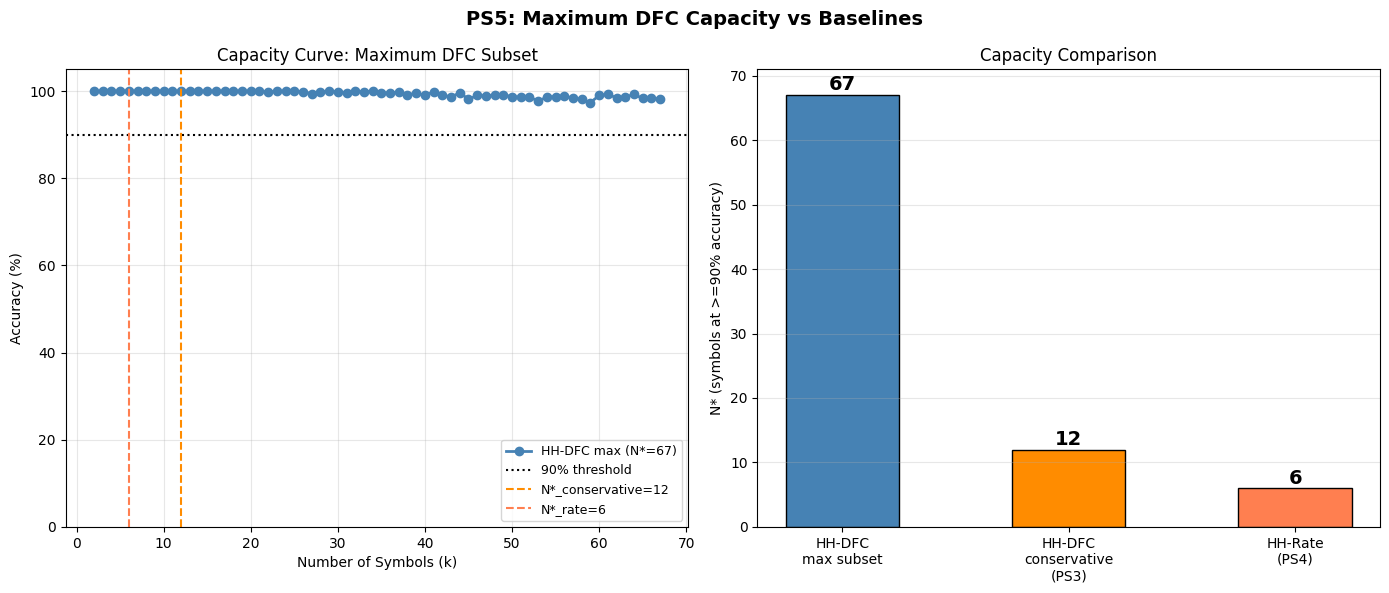


Saved: /content/drive/My Drive/HHSMC/full_study/PS5_max_capacity/PS5_max_capacity.json

PS5 COMPLETE
  Orbits loaded:    207
  Templates built:  207
  Max subset size:  67
  N*_max:           67
  N*_conservative:  12  (PS3)
  N*_rate:          6  (PS4)
  Gate PS-G5:       PASS


In [11]:
if __name__ == '__main__' or True:

    print('='*70)
    print('PS5 -- MAXIMUM CAPACITY: ALL 207 ORBIT TYPES')
    print('Option C: HH Delay-Directed Orbit Selection')
    print('='*70)

    I_BIAS         = 10.0
    N_CONSERVATIVE = 12   # from PS3
    N_RATE         = 6    # from PS4

    # === PHASE A: Load all orbits + build templates ===
    print('\n' + '='*50 + '\nPHASE A -- Load Orbits + Build Templates\n' + '='*50)
    all_orbits            = load_all_orbits(PS0_DIR)
    templates, skipped    = build_all_templates(
        all_orbits, I_bias=I_BIAS, T_sim=5000.0, T_trans=1000.0, n_runs=3)

    # === PHASE B: Pairwise confusion matrix ===
    print('\n' + '='*50 + '\nPHASE B -- Pairwise Confusion Matrix\n' + '='*50)
    acc_matrix = build_confusion_matrix(
        templates, I_bias=I_BIAS, n_windows=50,
        T_sim=5000.0, T_trans=500.0, n_isis=10)
    bad_pairs = analyze_confusion_matrix(acc_matrix, templates, threshold=0.90)
    plot_confusion_matrix(acc_matrix, templates,
                          threshold=0.90, save_dir=OUTPUT_DIR)

    # === PHASE C: Greedy max subset ===
    print('\n' + '='*50 + '\nPHASE C -- Greedy Maximum Subset\n' + '='*50)
    selected_idx = greedy_max_subset(acc_matrix, templates, threshold=0.90)

    # === PHASE D: Capacity curve ===
    print('\n' + '='*50 + '\nPHASE D -- Capacity Curve\n' + '='*50)
    cap_max = run_max_capacity(
        selected_idx, templates, I_bias=I_BIAS,
        n_trials=20, T_sim=3000.0, T_trans=500.0, n_isis=10)

    # === PHASE E + GATE PS-G5 ===
    gate = run_final_comparison_and_gate(
        cap_max['N_star_max'], N_CONSERVATIVE, N_RATE,
        selected_idx, templates)
    plot_capacity_comparison(cap_max, N_CONSERVATIVE, N_RATE,
                             save_dir=OUTPUT_DIR)

    # === SAVE ===
    def serial(o):
        if isinstance(o, np.ndarray): return o.tolist()
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        return o

    sel_templates = [templates[i] for i in selected_idx]
    out = {
        'timestamp':        datetime.now().isoformat(),
        'n_orbits_loaded':  len(all_orbits),
        'n_templates':      len(templates),
        'n_skipped':        len(skipped),
        'acc_matrix':       acc_matrix,
        'selected_indices': selected_idx,
        'selected_templates': sel_templates,
        'N_star_max':       cap_max['N_star_max'],
        'N_conservative':   N_CONSERVATIVE,
        'N_rate':           N_RATE,
        'capacity_results': cap_max['capacity_results'],
        'gate_PS_G5':       gate,
    }
    out_path = os.path.join(OUTPUT_DIR, 'PS5_max_capacity.json')
    with open(out_path, 'w') as f:
        json.dump(out, f, indent=2, default=serial)
    print(f'\nSaved: {out_path}')
    print('\n' + '='*70 + '\nPS5 COMPLETE\n' + '='*70)
    print(f'  Orbits loaded:    {len(all_orbits)}')
    print(f'  Templates built:  {len(templates)}')
    print(f'  Max subset size:  {len(selected_idx)}')
    print(f'  N*_max:           {cap_max["N_star_max"]}')
    print(f'  N*_conservative:  {N_CONSERVATIVE}  (PS3)')
    print(f'  N*_rate:          {N_RATE}  (PS4)')
    print(f'  Gate PS-G5:       {"PASS" if gate["pass"] else "FAIL"}')